# Notebook 2: Modelagem preditiva e o impacto das redes

**Objetivo:** Treinar algoritmos de classificação (Regressão Logística, Random Forest e XGBoost) para prever o risco de inadimplência. Vamos conduzir um teste rigoroso para cada algoritmo, comparando a abordagem tradicional (apenas variáveis financeiras) com a nossa abordagem enriquecida, que inclui as comunidades de Louvain e as métricas topológicas. Por fim, escolheremos qual o melhor modelo para entender como ele toma decisões.

# Importação de bibliotecas

In [1]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================
# %pip install xgboost  # (Descomentar caso precisar instalar no ambiente)
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# Configurações visuais globais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
import warnings
warnings.filterwarnings("ignore")

# Carregamento e preparação dos dados

In [2]:
# ==============================================================================
# 2. CARREGAMENTO DOS DADOS ENRIQUECIDOS (LOAD)
# ==============================================================================
print(">>> Iniciando o carregamento dos dados com features de grafos...")

file_path = '../data/processed/credit_data_with_network.parquet'
df = pd.read_parquet(file_path)

target_col = 'default.payment.next.month'
print(f"✅ Dados carregados com sucesso! Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# ==============================================================================
# 3. SEPARAÇÃO DAS FEATURES (VARIÁVEIS)
# ==============================================================================
# Variáveis tradicionais (histórico financeiro)
base_features = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

# Variáveis topológicas (comportamento social e coletivo)
network_features = ['network_pagerank', 'network_degree', 'network_clustering', 'network_louvain']
all_features = base_features + network_features

# Separação explícita de X e y
X = df[all_features]
y = df[target_col]

>>> Iniciando o carregamento dos dados com features de grafos...
✅ Dados carregados com sucesso! Dimensões: 30000 linhas e 29 colunas.



# Divisão de Treino/Teste e padronização espacial

Para garantir uma validação justa e evitar o vazamento de dados, separamos o conjunto mantendo a proporção original de inadimplentes (`stratify`). O escalonamento (`StandardScaler`) é ajustado estritamente na base de treino e apenas aplicado na base de teste.

In [3]:
# ==============================================================================
# 4. DIVISÃO EM TREINO E TESTE E PADRONIZAÇÃO
# ==============================================================================
print(">>> Dividindo o dataset e aplicando o Standard Scaler...")

# Divisão dos dados (70% Treino / 30% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# A Regressão Logística e o KNN necessitam dos dados na mesma escala (Z-score)
scaler = StandardScaler()

# Fit exclusivo no Treino
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=all_features, index=X_train.index)

# Apenas Transform no Teste
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=all_features, index=X_test.index)

print(f"✅ Separação concluída! Treino: {X_train.shape[0]} clientes | Teste: {X_test.shape[0]} clientes.\n")

>>> Dividindo o dataset e aplicando o Standard Scaler...
✅ Separação concluída! Treino: 21000 clientes | Teste: 9000 clientes.



# Comparação de modelos

Aqui conduzimos uma comparação entre modelos tradicionais e modelos com a Inteligência de Redes. O objetivo é observar se a Teoria dos Grafos e as comunidades do algoritmo de Louvain oferecem ganho real de performance preditiva (medido pelo indicador AUC).

In [4]:
# ==============================================================================
# 5. CONFIGURAÇÃO E TREINO DOS MODELOS
# ==============================================================================
# Dicionário com os 3 modelos para iteração
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

print(">>> Iniciando o treino e avaliação dos modelos (Isso pode levar alguns minutos)...\n")

for name, model in models.items():
    print(f"[{name}] Treinando...")
    
    # ---------------------------------------------------------
    # Modelo A: Baseline (apenas features tradicionais)
    # ---------------------------------------------------------
    model.fit(X_train_scaled[base_features], y_train)
    y_prob_base = model.predict_proba(X_test_scaled[base_features])[:, 1]
    auc_base = roc_auc_score(y_test, y_prob_base)
    fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
    
    # ---------------------------------------------------------
    # Modelo B: Network-Enhanced (tradicionais + rede)
    # ---------------------------------------------------------
    model.fit(X_train_scaled[all_features], y_train)
    y_prob_net = model.predict_proba(X_test_scaled[all_features])[:, 1]
    auc_net = roc_auc_score(y_test, y_prob_net)
    fpr_net, tpr_net, _ = roc_curve(y_test, y_prob_net)
    
    # Guarda os resultados e o próprio modelo treinado no dicionário
    results[name] = {
        'auc_base': auc_base, 'fpr_base': fpr_base, 'tpr_base': tpr_base,
        'auc_net': auc_net, 'fpr_net': fpr_net, 'tpr_net': tpr_net,
        'model_obj': model # Guarda a última versão (com redes) para a análise de features
    }
    print(f"   -> AUC Baseline: {auc_base:.4f} | AUC c/ Redes: {auc_net:.4f}\n")

print("✅ Treinamento finalizado!")

>>> Iniciando o treino e avaliação dos modelos (Isso pode levar alguns minutos)...

[Logistic Regression] Treinando...
   -> AUC Baseline: 0.7150 | AUC c/ Redes: 0.7195

[Random Forest] Treinando...
   -> AUC Baseline: 0.7741 | AUC c/ Redes: 0.7736

[XGBoost] Treinando...
   -> AUC Baseline: 0.7759 | AUC c/ Redes: 0.7719

✅ Treinamento finalizado!


# Curvas ROC

A Curva ROC (Receiver Operating Characteristic) ilustra a capacidade dos modelos de distinguir entre a classe positiva (inadimplentes) e a classe negativa (bons pagadores) em diversos limiares de decisão. Comparamos visualmente o ganho do modelo com redes (linha vermelha) frente ao modelo tradicional (linha azul).

>>> Gerando painel comparativo de Curvas ROC...
✅ Gráficos gerados e salvos com sucesso!



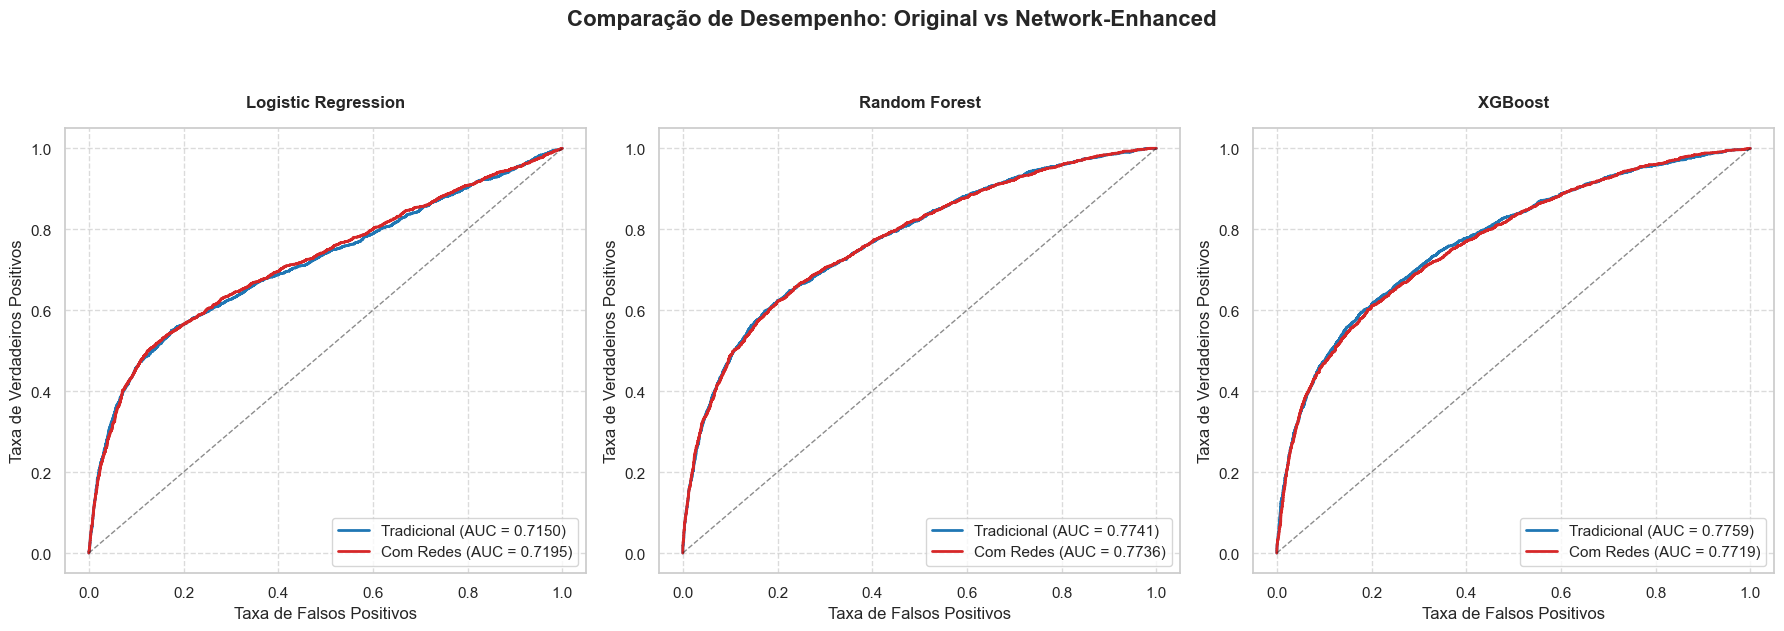

In [5]:
# ==============================================================================
# 6. VISUALIZAÇÃO DOS RESULTADOS (CURVAS ROC)
# ==============================================================================
print(">>> Gerando painel comparativo de Curvas ROC...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparação de Desempenho: Original vs Network-Enhanced', fontsize=16, fontweight='bold', y=1.05)

for ax, (name, metrics) in zip(axes, results.items()):
    # Plota o modelo Original
    ax.plot(metrics['fpr_base'], metrics['tpr_base'], label=f'Tradicional (AUC = {metrics["auc_base"]:.4f})', color='#1f77b4', lw=2)
    # Plota o modelo com Redes
    ax.plot(metrics['fpr_net'], metrics['tpr_net'], label=f'Com Redes (AUC = {metrics["auc_net"]:.4f})', color='#d62728', lw=2)
    
    # Linha de aleatoriedade
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    
    ax.set_title(name, fontweight='bold', pad=15)
    ax.set_xlabel('Taxa de Falsos Positivos')
    ax.set_ylabel('Taxa de Verdadeiros Positivos')
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.7)

# Exportação e exibição
plt.tight_layout()
plt.savefig('../assets/img/roc_curves_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráficos gerados e salvos com sucesso!\n")
plt.show()

# Importância das variáveis

Vamos analisar quais informações foram consideradas as mais importantes para tornar o XGBoost o modelo com melhores resultados.

>>> Extraindo a importância relativa das variáveis no XGBoost (baseline)...
✅ Gráfico gerado e salvo com sucesso!



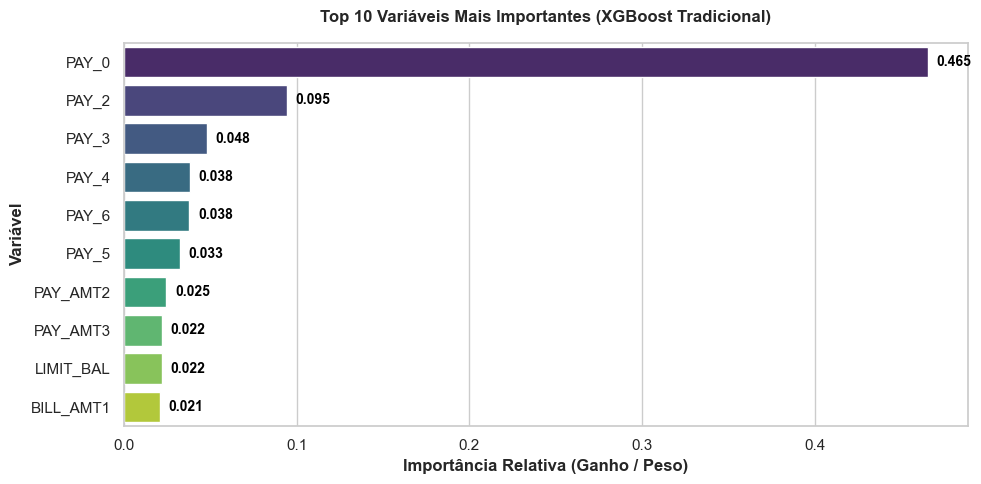

In [6]:
# ==============================================================================
# 7. IMPORTÂNCIA DAS VARIÁVEIS (FEATURE IMPORTANCE DO XGBOOST BASELINE)
# ==============================================================================
print(">>> Extraindo a importância relativa das variáveis no XGBoost (baseline)...")

# Recuperamos o XGBoost treinado (último fit foi com todas as features,
# então precisamos retreinar apenas com as features base)
best_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
best_model.fit(X_train_scaled[base_features], y_train)

importances = best_model.feature_importances_

# Criamos um DataFrame para ordenar
df_imp = pd.DataFrame({'Feature': base_features, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False).head(10)

# Visualização no formato de barras horizontais
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')

plt.title('Top 10 Variáveis Mais Importantes (XGBoost Tradicional)', fontweight='bold', pad=15)
plt.xlabel('Importância Relativa (Ganho / Peso)', fontweight='bold')
plt.ylabel('Variável', fontweight='bold')

# Adiciona os valores no final de cada barra para facilitar a leitura
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}', 
                (p.get_width() + 0.005, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, fontweight='bold', color='black')

# Exportação e exibição
plt.tight_layout()
plt.savefig('../assets/img/feature_importance_xgboost.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico gerado e salvo com sucesso!\n")
plt.show()